---
title: "Nielsen's NNDL, ch.3A"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: true
    code-summary: "Show the code"
---

## introduction

Nielsen's chapter 3 is quite long, so in this part A I will discuss only the subject of how to model the output of our neural network, and the impact this has on the cost function we use to train our network.

Nielsen discusses the usage of cross entropy as a better cost function for our classification problem. He argues why it does a better job at avoiding training slowdown due to neuron saturation, and gives some intuition of why the formula makes sense. I'll give below my own take on this subject, starting from something deeper than the cost function: how we choose to model the output our neural network gives us.

## modeling the network's output

Our fundamental task is to interpret the output the neural network gives us. Once we choose an interpretation, we can use the idea of maximizing the likelihood as the central optimization procedure.

Let's define a few variables, they will make our discussion more efficient.

* $X$ is the random variable representing the input, here the images of written digits. $x$ is a specific value of $X$, meaning a specific image of a written digit.
* $Y$ is the random variable representing the output, meaning the activation values in the output layer. $y$ is a specific value of $Y$, meaning a specific vector of activation values in the output layer.
* $\theta$ is the set of parameters of our neural network, meaning the weights and biases.
* $f_\theta(x)$ is the function that our neural network computes. Given an input $x$ and a set of parameters $\theta$, it gives us the output of the network, which is a vector of activations in the output layer.

### gaussian model

We could choose to model the output of our network with a gaussian distribution. In this case, we would write:

$$
Y \mid (X=x) \sim \mathcal{N}(f_\theta(X), \sigma^2).
$$

Let's translate that into words: we are saying that the output of our network, given a specific input $x$, is a random variable that follows a normal distribution with mean $f_\theta(x)$ and variance $\sigma^2$. In other words, we are modeling the output of our network as a noisy version of the function $f_\theta(x)$, where the noise is normally distributed with mean 0 and variance $\sigma^2$.

There is something important to say here: the neural network is a deterministic function, meaning that given an input $x$ and a set of parameters $\theta$, it will always give us the same output. However, we are **modeling** the output as a random variable. Doing so allows us to use the tools of probability to analyze and optimize our network.

As we discussed in the chapter on [maximum likelihood estimation](/likelihood/MLE_and_summary_statistics.html#normal-distribution), when we model our data as a normal distribution, the log-likelihood of our data is proportional to the negative MSE. This means that maximizing the log-likelihood is equivalent to minimizing the MSE.

The take-home message here is that when we choose the MSE as our cost function, we are implicitly modeling the output of our network as a gaussian distribution. Did we have good reasons to choose this model? No, we will see in a while a much more sensible choice. The point here is that any choice of cost function corresponds to a choice of model for the output of our network, whether we are aware of it or not.

## bernoulli model

We are dealing with a classification problem. Every input image has one unique label, which is the digit that the image represents. The output layer of our network has 10 neurons, each one representing a digit from 0 to 9. We can interpret the activation value in each of these neurons as a Bernoulli trial. We discussed Bernoulli processes in the chapter about [conjugate priors](/bayes/conjugate-prior.html#modeling-the-likelihood), where we used Bayes' theorem to update our belief about the probability of rainfall. Fundamentally, a Bernoulli trial is a process that yields only two possible outcomes: success (1) or failure (0). In the context of rainfall, success meant that it did rain in a given day, and failure meant that it didn't. In our digit classification problem, success at the neuron 0 of our output layer means that the network identifies the input $x$ as representing the digit 0, and failure means that the network does not identify it. More generally, success at the $j$ neuron means that the network identifies the digit $j$.

Once more, it is important to remember that our network is absolutely deterministic, but for convenience we choose to model the output as a random process. When modeling the output as a Bernoulli trial whose probability of success is $p$, we write the following probability distribution:

$$
P(Y_j = y \mid X=x) = a_j(x)^y (1 - a_j(x))^{1-y}.
$$

Let's break this down. $y=1$ represents success, meaning that the network identifies the input $x$ as representing the digit $j$. Plugging $y=1$ into the formula gives us $a_j(x)^1 (1 - a_j(x))^{1-1} = a_j(x)$. In this case, the probability of success is $a_j(x)$, which is the activation value of the $j$ neuron in the output layer. On the other hand, $y=0$ represents failure, meaning that the network does not identify the input $x$ as representing the digit $j$. In this case, plugging $y=0$ into the formula gives us $a_j(x)^0 (1 - a_j(x))^{1-0} = 1 - a_j(x)$. The probability of failure is therefore $1 - a_j(x)$. 

We now have two choices to go forward, depending if we want to allow for multiple neurons to be active at the same time or not.

## multi-label classification

Sometimes, classification problems do allow for multiple labels to be active at the same time. For example, if we are classifying images of animals, we could be interested in identifying if the image contains a cat, a dog, a bear, a rabbit, etc. Some pictures will only contain one of these animals, but others could contain more than one, and still others could contain none of them. In this case, we treat each of the output neurons as an **independent** Bernoulli trial. For example, success at the neuron 0 means that the network identifies a cat in the image, success at the neuron 1 means that the network identifies a dog, failure at the neuron 2 means that the network does not identify a bear, and so on. The presence or absence of one animal does not affect the presence or absence of the others, so we can model each neuron as an independent Bernoulli trial. Because of this independence, the probability distribution of the output of our network is the product of the probability distributions of each neuron:

$$
P(Y = y \mid X=x) = \prod_{j=0}^{9} a_j(x)^{y_j} (1 - a_j(x))^{1-y_j}.
$$

Finally, using the idea of maximizing the log-likelihood to optimize our network, we can derive the cost function that we will use to train our network. The log-likelihood of our data is given by:

$$
\log P(Y = y \mid X=x) = \sum_{j=0}^{9} \left[y_j \log a_j + (1 - y_j) \log (1 - a_j)\right].
$$

Instead of maximizing the log-likelihood, we can minimize the negative log-likelihood, which gives us the following cost function:

$$
C = -\sum_{j} \left[y_j \log a_j + (1 - y_j) \log (1 - a_j)\right].
$$

This is the cost function for a specific training example $x$. To get the cost function for the entire training set, we take the average over all training examples:

$$
C = -\frac{1}{n} \sum_{x} \sum_{j} \left[y_j \log a_j + (1 - y_j) \log (1 - a_j)\right].
$$

And this is equation (63) in Nielsen's book. This is called the binary cross-entropy cost function.

## single-label classification

As the name suggests, only one label can be active at the same time. In our digit classification problem, this means that the input image can only represent one digit, so only one of the output neurons can be active at the same time. In this case, we can model the output of our network as a categorical distribution, which is a generalization of the Bernoulli distribution for more than two outcomes. The probability distribution of the output of our network is given by:

$$
P(Y = y \mid X=x) = \prod_{j=0}^{9} a_j(x)^{y_j}.
$$

The difference between this formula and the one we had for the multi-label classification is that we don't have the term $(1 - a_j(x))^{1-y_j}$, which represents the probability of failure. This is because in single-label classification, we are not interested in modeling the probability of failure, since only one label can be active at the same time. Let's give an example to make this clearer. If the input image represents the digit 3, then $y_3$ will be 1 and all the other $y_j$ will be 0. This is how hot one encoding works. Our the label vector and activation vector in the output layer will be something like:

$$
y_j(x)
=
\begin{bmatrix}
0 \\
0 \\
0 \\
1 \\
0 \\
0 \\
0 \\
0 \\
0 \\
0
\end{bmatrix}
\qquad
a_j(x)
=
\begin{bmatrix}
0.0 \\
0.1 \\
0.0 \\
0.7 \\
0.1 \\
0.1 \\
0.0 \\
0.0 \\
0.0 \\
0.0
\end{bmatrix}
$$

It's easy to see that the probability of success in this case is $a_3(x) = 0.7$, which is the activation value of the neuron representing the digit 3, since all other activation values are raised to the power of 0 and therefore do not contribute to the product.

The log-likelihood of our data is given by:

$$
\log P(Y = y \mid X=x) = \sum_{j=0}^{9} y_j \log a_j.
$$

We can define the cost function as the negative log-likelihood, which gives us:

$$
C = -\sum_{j} y_j \log a_j,
$$

which is equation (80) in Nielsen's book. This is called the categorical cross-entropy cost function.

## softmax

We made an assumption in the case of single-label classification: the activation vector in the output layer is a valid probability distribution, meaning that all activation values are between 0 and 1, and they sum to 1. If this is not the case, we can use the softmax function to transform the activation vector into a valid probability distribution. The softmax function is defined as follows:

$$
a_j(x) = \frac{e^{z_j}}{\sum_{k=0}^{9} e^{z_k}},
$$

where $z_j$ is the weighted input to the $j$ neuron in the output layer.

It is easy to see why this procedure produces a valid probability distribution. 

1. All activation values are positive, since the exponential function is always positive. 
1. The sum of all activation values is 1, since:
$$
\sum_{j=0}^{9} a_j(x) = \sum_{j=0}^{9} \frac{e^{z_j}}{\sum_{k=0}^{9} e^{z_k}} = \frac{\sum_{j=0}^{9} e^{z_j}}{\sum_{k=0}^{9} e^{z_k}} = 1.
$$

Because we can apply the softmax function directly to the weighted input of the output layer, we don't need anymore the sigmoid function. The whole idea of the sigmoid was to squash the activation values between 0 and 1. The softmax does that, and it also ensures that the activation values sum to 1, which is a requirement for a valid probability distribution.

## binary or categorical

Let's summarize what we have seen so far.

1. If we choose to model the output of our network as a gaussian distribution, we get the MSE cost function. This is a bad choice, because the gaussian distribution is not a good model for the output of our network in a classification problem.
1. If we choose to model the output of our network as a Bernoulli distribution, we get the binary cross-entropy cost function. This is a good choice for multi-label classification problems, where multiple labels can be active at the same time. In that case all we have to guarantee is that the activation values are between 0 and 1, which is easy to achieve with a sigmoid function.
1. If we choose to model the output of our network as a categorical distribution, we get the categorical cross-entropy cost function. This is a good choice for single-label classification problems, where only one label can be active at the same time. In that case we have to guarantee that the activation values are between 0 and 1 and they sum to 1, which is easy to achieve with a softmax function.

In our digit classification problem, we are dealing with a single-label classification problem, since each input image can only represent one digit. Therefore, the most sensible choice is to model the output of our network as a categorical distribution, which gives us the categorical cross-entropy cost function. However, choosing the binary cross-entropy cost function also works. All the examples in the dataset have only one label active at the same time, so the cost function will only take into account the activation value of the neuron representing the correct digit, and it will ignore the activation values of the other neurons. Therefore, in this specific case, both cost functions should give us the same result. However, in general, it is better to choose the cost function that corresponds to the model we have for our data, which in this case is the categorical distribution.

## exercise A

Given

$$
\sigma(z) = \frac{1}{1 + e^{-z}},
$$

::: {.card .bg-info .card-body .pb-0}
Verify that
$$
\sigma'(z)=\sigma(z)(1−\sigma(z)).
$$
:::
<br>

\begin{align*}
\frac{d}{dz} \sigma(z) &= \frac{d}{dz} \left( \frac{1}{1 + e^{-z}} \right) \\
&= \frac{-e^{-z}}{-(1 + e^{-z})^2} \\
&= \underbrace{\frac{1}{1 + e^{-z}}}_{\sigma(z)} \cdot \frac{e^{-z}}{1 + e^{-z}} \\
&= \sigma(z) \left[\frac{1 + e^{-z} - 1}{1 + e^{-z}} \right] = \sigma(z) \left[1 - \frac{1}{1 + e^{-z}} \right]\\
&= \sigma(z)(1 - \sigma(z)).
\end{align*}

## gradient of MSE and cross-entropy cost functions

Let's start with the MSE cost function, as defined in the previous chapter:

$$
C_x = \frac{1}{2} \sum_j \left( y_j - a^L_j\right)^2.
$$

The gradient of this cost function with respect to the parameters of the network at the output layer is given by:

$$
\nabla C_x = \left( \frac{\partial C_x}{\partial w^L_{jk}}, \frac{\partial C_x}{\partial b^L_{j}} \right)
$$

Let's use the chain rule to compute the partial derivatives. We have:

\begin{align*}
\frac{\partial C_x}{\partial w^L_{jk}} &= \frac{\partial C_x}{\partial a^L_j} \cdot \frac{\partial a^L_j}{\partial z^L_j} \cdot \frac{\partial z^L_j}{\partial w^L_{jk}} \\
&= (a^L_j - y_j) \cdot \sigma'(z^L_j) \cdot a^{L-1}_k,
\end{align*}

Doing the same for the bias, we get:

\begin{align*}
\frac{\partial C_x}{\partial b^L_{j}} &= \frac{\partial C_x}{\partial a^L_j} \cdot \frac{\partial a^L_j}{\partial z^L_j} \cdot \frac{\partial z^L_j}{\partial b^L_{j}} \\
&= (a^L_j - y_j) \cdot \sigma'(z^L_j) \cdot 1.
\end{align*}

This derivation is different from Nielsen's, because he considers a neural network with only one layer made of a single neuron. This really helps to simplify the math and show his point, but the same can be understood for our more general case.

The important point is what happens to this gradient as the sigmoid function saturates, either because $z^L_j$ is very large or because it is very small. See the graph below.

In [1]:
#| code-summary: "import libraries"
import numpy as np
import matplotlib.pyplot as plt

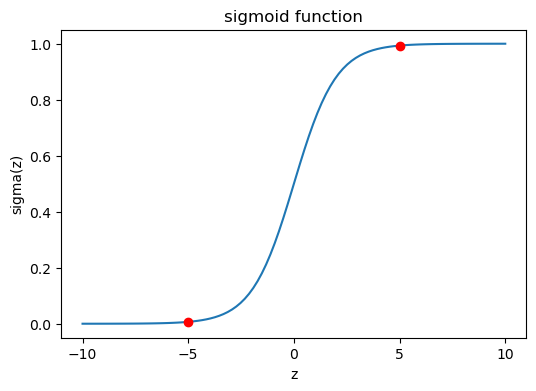

In [7]:
#| code-summary: "plot sigmoid"
fig, ax = plt.subplots(figsize=(6, 4))
z = np.linspace(-10, 10, 100)
sigma = lambda z: 1 / (1 + np.exp(-z))
z_star = 5
ax.plot(z, sigma(z))
ax.plot([z_star, -z_star], [sigma(z_star), sigma(-z_star)], 'ro')
ax.set(xlabel='z',
       ylabel='sigma(z)',
       title='sigmoid function',
       xticks=[-10, -5, 0, 5, 10],);

If $z$ is high enough (way to the right), or low enough (way to the left), the derivative $\sigma'(z)$ approaches zero. We already proved that $\sigma'(z) = \sigma(z)(1 - \sigma(z))$. As the absolute value of $z$ increases, either $\sigma$ or $1-\sigma$ is guaranteed to approach zero, making the whole product $\sigma(1 - \sigma)$ approach zero.

This explains why the MSE cost function can lead to training slowdown due to neuron saturation.

Now let's compute the gradient of the binary cross-entropy cost function. Using the chain rule, we have the same expression as before:

\begin{align*}
\frac{\partial C_x}{\partial w^L_{jk}} &= \frac{\partial C_x}{\partial a^L_j} \cdot \frac{\partial a^L_j}{\partial z^L_j} \cdot \frac{\partial z^L_j}{\partial w^L_{jk}} \\
\frac{\partial C_x}{\partial b^L_{j}} &= \frac{\partial C_x}{\partial a^L_j} \cdot \frac{\partial a^L_j}{\partial z^L_j} \cdot \frac{\partial z^L_j}{\partial b^L_{j}}
\end{align*}

Now let's compute the partial derivative $\partial C_x / \partial a^L_j$:

\begin{align*}
\frac{\partial C_x}{\partial a^L_j} &=
\frac{\partial}{\partial a^L_j} \left( - \left[y_j \log a_j + (1 - y_j) \log (1 - a_j)\right] \right)\\
&= -\frac{y_j}{a_j} + \frac{1 - y_j}{1 - a_j} \\
&= \frac{a_j - y_j}{a_j(1 - a_j)}\\
& = \frac{\sigma(z_j) - y_j}{\sigma(z_j)(1 - \sigma(z_j))}.
\end{align*}

In the last step, we used the fact that $a_j = \sigma(z_j)$.

Now the partial derivative $\partial a^L_j / \partial z^L_j$:

$$
\frac{\partial a^L_j}{\partial z^L_j} = \frac{\partial}{\partial z^L_j} \sigma(z^L_j) = \sigma'(z^L_j) = \sigma(z^L_j)(1-\sigma(z^L_j)).
$$

Lastly, we have that $\partial z^L_j / \partial w^L_{jk} = a^{L-1}_k$, and $\partial z^L_j / \partial b^L_{j} = 1$.

Putting everything together, we get:

\begin{align*}
\frac{\partial C_x}{\partial w^L_{jk}}
&=
\frac{\sigma(z_j^L) - y_j}{\sigma(z_j^L)(1 - \sigma(z_j^L))}
\sigma(z^L_j)(1-\sigma(z^L_j))
a^{L-1}_k \\
&= (a_j^L - y_j)a^{L-1}_k
\end{align*}

and

\begin{align*}
\frac{\partial C_x}{\partial b^L_{j}}
&=
\frac{\sigma(z_j^L) - y_j}{\sigma(z_j^L)(1 - \sigma(z_j^L))}
\sigma(z^L_j)(1-\sigma(z^L_j)) \\
&= a_j^L - y_j
\end{align*}

Note that I converted $\sigma(z_j)$ to $a_j$ in the last step, since they are the same thing.

That's incredible! This expression is *much* simpler that the one for the MSE! Let's see them side by side in a table:

| Cost function | Gradient with respect to weights | Gradient with respect to biases |
| --- | --- | --- |
| MSE | $(a^L_j - y_j) \cdot a^{L-1}_k \cdot \sigma'(z^L_j)$ | $(a^L_j - y_j) \cdot \sigma'(z^L_j)$ |
| Binary cross-entropy | $(a_j^L - y_j)\cdot a^{L-1}_k$ | $a_j^L - y_j$ |

The expressions are exactly the same, but for the absence of $\sigma'(z^L_j)$ in the binary cross-entropy case. The gradient for the cross-entropy is directly proportional to the error $a_j^L - y_j$: if the estimated probability $a_j^L$ is far from the true label $y_j$, the gradient will be large, and we will make a big update to the weights and biases. If the estimated probability is close to the true label, the gradient will be small, and we will make a small update.

## exercise B

::: {.card .bg-info}
::: {.card-header}
[what's the right order?]{.h3}
:::
::: {.card-body .pb-0}
One gotcha with the cross-entropy is that it can be difficult at first to remember the respective roles of the $y$s and the $a$s. It's easy to get confused about whether the right form is
$$
−[y \ln a+(1−y)\ln(1−a)]
$$

or

$$
−[a\ln y+(1−a)\ln(1−y)].
$$

What happens to the second of these expressions when $y=0$ or $1$? Does this problem afflict the first expression? Why or why not? 
:::
:::
<br>

In the second expression, if $y$ is 0 or 1, we get a zero argument inside one of the logarithms, which is undefined. In the first expression, if $y$ is 0 or 1, we simply turn off one of the terms.


## exercise C

::: {.card .bg-info}
::: {.card-header}
[header here]{.h3}
:::
::: {.card-body .pb-0}
In the single-neuron discussion at the start of this section, I argued that the cross-entropy is small if $\sigma(z)\sim y$ for all training inputs. The argument relied on y being equal to either 0 or 1. This is usually true in classification problems, but for other problems (e.g., regression problems) y can sometimes take values intermediate between 0 and 1. Show that the cross-entropy is still minimized when $\sigma(z)=y$ for all training inputs. When this is the case the cross-entropy has the value:
$$
C=−\frac{1}{n}\sum_x[y\ln y+(1−y)\ln(1−y)]
$$

The quantity $−[y\ln y+(1−y)\ln(1−y)]$ is sometimes known as the binary entropy.
:::
:::
<br>

To show that the cross-entropy is minimized when $\sigma(z) = y$ for all training inputs, we can take the derivative of the cross-entropy cost function with respect to $\sigma(z)$ and set it to zero. The cross-entropy cost function for a single training example is given by:

$$
C = -\left[y \ln \sigma(z) + (1 - y) \ln (1 - \sigma(z))\right].
$$

Taking the derivative with respect to $\sigma(z)$, would be the same as taking the derivative with respect to $a$, since $a = \sigma(z)$. Since we already did that in the previous exercise, we can just reuse the result:

$$
\frac{dC}{d\sigma(z)} = \frac{\sigma(z) - y}{\sigma(z)(1 - \sigma(z))}.
$$

Setting this derivative to zero, we get:

$$
\frac{\sigma(z) - y}{\sigma(z)(1 - \sigma(z))} = 0.
$$

This implies that $\sigma(z) - y = 0$, which means that $\sigma(z) = y$. Therefore, the cross-entropy is minimized when $\sigma(z) = y$ for all training inputs.

When $\sigma(z) = y$, the cross-entropy cost function becomes:

$$
C = -\left[y \ln y + (1 - y) \ln (1 - y)\right].
$$



## exercise D

::: {.card .bg-info}
::: {.card-header}
[header here]{.h3}
:::
::: {.card-body .pb-0}
We've discussed at length the learning slowdown that can occur when output neurons saturate, in networks using the quadratic cost to train. Another factor that may inhibit learning is the presence of the $x_j$ term in Equation (61). Because of this term, when an input $x_j$ is near to zero, the corresponding weight $w_j$ will learn slowly. Explain why it is not possible to eliminate the $x_j$ term through a clever choice of cost function. 
:::
:::
<br>

Nielsen is referring to the equation 

$$
\frac{\partial C}{\partial w_j} = \frac{1}{n}\sum_x x_j \left(\sigma(z) - y\right),
$$

which for us looks like this: $(a_j^L - y_j)\cdot a^{L-1}_k$. We write $a^{L-1}_k$ instead of $x_j$ because Nielsen considered the very simplest case of a neural network with only one layer made of a single neuron. In any case, the answer will be the same for both cases.

The reason that a "clever choice" of cost function cannot eliminate the $x_j$ term (or the $a^{L-1}_k$ term) stems from the expression for the chain rule:

$$
\frac{\partial C_x}{\partial w^L_{jk}} = \frac{\partial C_x}{\partial a^L_j} \cdot \frac{\partial a^L_j}{\partial z^L_j} \cdot \frac{\partial z^L_j}{\partial w^L_{jk}}.
$$

Changing our choice of cost function will affect the first partial derivative only, but we know that the last partial derivative is the one responsible for the presence of the $x_j$ term, so nothing will help.

## exercise E

::: {.card .bg-info}
::: {.card-header}
[activations $\neq$ pdf]{.h3}
:::
::: {.card-body .pb-0}
Construct an example showing explicitly that in a network with a sigmoid output layer, the output activations aLj won't always sum to 1. 
:::
:::
<br>

I don't feel like coming up with a specific example. Instead, I'll just run the code we wrote in the previous chapter and show this for a specific input image.


In [ ]:
#| code-summary: "import libraries"
import os
import io
import gzip
import numpy as np
import requests
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.patches as patches
import json
import time

from ch2_code import *

In [11]:
#| code-summary: "load MNIST data into memory"
training_data, test_data = load_mnist_from_web()
print(f"Loaded {len(training_data)} training samples directly into memory.")

Fetching train_img...
Fetching train_lbl...
Fetching test_img...
Fetching test_lbl...
Loaded 60000 training samples directly into memory.


In [12]:
net = NN(layer_sizes=[784, 30, 10], activation="sigmoid", rand_seed=3)
net.stochastic_gradient_descent(training_data=training_data,
        epochs=10,
        batch_size=100,
        eta=10,
        test_data=test_data)

Epoch  1/10: 100%|██████████| 00:01


Accuracy: 86.38% | Runtime: 1.808 seconds


Epoch  2/10: 100%|██████████| 00:02


Accuracy: 90.19% | Runtime: 2.318 seconds


Epoch  3/10: 100%|██████████| 00:02


...

Accuracy: 93.71% | Runtime: 1.040 seconds


Epoch  9/10: 100%|██████████| 00:01


Accuracy: 93.89% | Runtime: 1.088 seconds


Epoch 10/10: 100%|██████████| 00:01


Accuracy: 94.05% | Runtime: 1.219 seconds


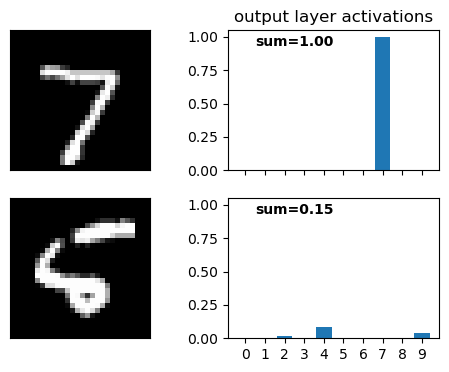

In [43]:
fig, ax = plt.subplots(2, 2, figsize=(6, 4), sharex="col", sharey="col")

ax[0,0].imshow(test_data[0][0].reshape(28, 28), cmap='gray')
ax[1,0].imshow(test_data[8][0].reshape(28, 28), cmap='gray')
ax[0,0].set(xticks=[],
            yticks=[],
            )
bars0 = net.feedforward(test_data[0][0]).flatten()
bars1 = net.feedforward(test_data[8][0]).flatten()
ax[0,1].bar(range(10), bars0)
ax[1,1].bar(range(10), bars1)

ax[0,1].text(0.5, 0.97, r"sum={:.2f}".format(bars0.sum()), transform=ax[0,1].transAxes,
         horizontalalignment='right', verticalalignment='top',
         fontweight="bold")

ax[1,1].text(0.5, 0.97, r"sum={:.2f}".format(bars1.sum()), transform=ax[1,1].transAxes,
         horizontalalignment='right', verticalalignment='top',
         fontweight="bold")


ax[0,1].set(xticks=range(10),
            title="output layer activations"
            );

Surprisingly, most test images yielded activations that sum very close to 1, even without applying the softmax function. The second image in the figure above is not very readable, and maybe because of that the activations sum to only 0.15. See below the sum of the activations in the output layer for the first 20 test images:

In [46]:
for i in range(20):
    bars = net.feedforward(test_data[i][0]).flatten()
    print(f"Image {i:2d}: Sum of activations = {bars.sum():.2f}")


Image  0: Sum of activations = 1.00
Image  1: Sum of activations = 1.00
Image  2: Sum of activations = 0.99
Image  3: Sum of activations = 0.99
Image  4: Sum of activations = 1.01
Image  5: Sum of activations = 1.09
Image  6: Sum of activations = 0.99
Image  7: Sum of activations = 1.02
Image  8: Sum of activations = 0.15
Image  9: Sum of activations = 1.03
Image 10: Sum of activations = 1.00
Image 11: Sum of activations = 0.99
Image 12: Sum of activations = 1.01
Image 13: Sum of activations = 1.00
Image 14: Sum of activations = 1.00
Image 15: Sum of activations = 0.65
Image 16: Sum of activations = 1.04
Image 17: Sum of activations = 1.00
Image 18: Sum of activations = 0.30
Image 19: Sum of activations = 1.00


## exercise F

::: {.card .bg-info}
::: {.card-header}
[Monotonicity of softmax]{.h3}
:::
::: {.card-body .pb-0}
Show that ${\partial a^L_j}/{\partial z^L_k}$ is positive if $j=k$ and negative if $j \neq k$. As a consequence, increasing $z^L_j$ is guaranteed to increase the corresponding output activation, $a^L_j$, and will decrease all the other output activations. We already saw this empirically with the sliders, but this is a rigorous proof.
:::
:::
<br>

The formula for the softmax is given by

$$
a_j = \frac{e^{z_j}}{\sum_{k=0}^{9} e^{z_k}}.
$$

Without loss of generality, assume we are varying the weighted output $z_0$. How will $a_0$ respond?

$$
\frac{\partial a_0}{\partial z_0} = \frac{\partial}{\partial z_0} \frac{e^{z_0}}{e^{z_0} + C},
$$

where the constant above is simply the sum $\sum_{k=1}^9e^{z_k}$.

\begin{align*}
\frac{\partial a_0}{\partial z_0} &= \frac{\partial}{\partial z_0}\frac{e^{z_0}}{e^{z_0} + C} \\
&= \frac{e^{z_0}(e^{z_0} + C) - e^{z_0}e^{z_0}}{(e^{z_0} + C)^2} \\
&= \frac{e^{z_0}C}{(e^{z_0} + C)^2} \\
&> 0.
\end{align*}

Now, how will $a_1$ respond to an increase in $z_0$?

\begin{align*}
\frac{\partial a_1}{\partial z_0} &=
\frac{\partial}{\partial z_0} \frac{e^{z_1}}{e^{z_0} + C} \\
&= \frac{-e^{z_1}e^{z_0}}{(e^{z_0} + C)^2} \\
&< 0.
\end{align*}

## exercise G

::: {.card .bg-info}
::: {.card-header}
[Non-locality of softmax]{.h3}
:::
::: {.card-body .pb-0}
A nice thing about sigmoid layers is that the output $a^L_j$ is a function of the corresponding weighted input, $a^L_j = \sigma(z^L_j)$. Explain why this is not the case for a softmax layer: any particular output activation $a^L_j$ depends on all the weighted inputs.
:::
:::
<br>

This is easy to see from the formula for the softmax:

$$
a_j = \frac{e^{z_j}}{\sum_{k=0}^{9} e^{z_k}}.
$$

The denominator is the same for all output activations, so changing any of the weighted inputs $z_k$ will affect all the output activations $a_j$.

## exercise H

::: {.card .bg-info}
::: {.card-header}
[Inverting the softmax layer]{.h3}
:::
::: {.card-body .pb-0}
Suppose we have a neural network with a softmax output layer, and the activations $a^L_j$ are known. Show that the corresponding weighted inputs have the form $z^L_j = \ln(a^L_j) + C$, for some constant $C$ that is independent of $j$. 
:::
:::
<br>

The formula for the softmax is given by
$$
a_j = \frac{e^{z_j}}{\sum_{k=0}^{9} e^{z_k}} = \frac{e^{z_j}}{Z},
$$

where $Z$ is the normalization constant defined as $Z = \sum_{k=0}^{9} e^{z_k}$. Solving the equation above for $z_j$, we get:

$$
z_j = \ln(a_j) + \ln(Z) = \ln(a_j) + C,
$$

which proves the statement.

## exercise I

::: {.card .bg-info}
::: {.card-header}
[Where does the "softmax" name come from? ]{.h3}
:::
::: {.card-body .pb-0}
Suppose we change the softmax function so the output activations are given by

$$
a^L_j = \frac{e^{cz^L_j}}{\sum_k e^{cz^L_k}}
$$

where $c$ is a positive constant. Note that $c=1$ corresponds to the standard softmax function. But if we use a different value of $c$ we get a different function, which is nonetheless qualitatively rather similar to the softmax. In particular, show that the output activations form a probability distribution, just as for the usual softmax. Suppose we allow $c$ to become large, i.e., $c→∞$. What is the limiting value for the output activations $a^L_j$? After solving this problem it should be clear to you why we think of the $c=1$ function as a "softened" version of the maximum function. This is the origin of the term "softmax".
:::
:::
<br>

To show that the output activations form a pdf, we need to show that each activation is a positive number, and that the sum of all activations is 1.

* From the formula, it is clear that all activations are positive, since the exponential function is positive.
* Let's compute $\sum a_j$:
  $$
  \sum_j a_j = \sum_j \frac{e^{c z_j}}{\sum_k e^{c z_k}} = \frac{\sum_j e^{c z_j}}{\sum_k e^{c z_k}} = 1.
  $$
  This is true regardless of the value of $c$.

Now, let's see what happens when $c$ becomes large. As $c \to \infty$, the term $e^{c z_j}$ will dominate the sum in the denominator for the largest value of $z_j$. Let's denote $z_{max} = \max_j z_j$. Then, as $c \to \infty$, we have:
$$
a_j = \frac{e^{c z_j}}{\sum_k e^{c z_k}} \approx \frac{e^{c z_j}}{e^{c z_{max}}} = e^{c (z_j - z_{max})}.
$$
If $z_j < z_{max}$, then $z_j - z_{max} < 0$, and as $c \to \infty$, $e^{c (z_j - z_{max})} \to 0$. If $z_j = z_{max}$, then $z_j - z_{max} = 0$, and $e^{c (z_j - z_{max})} = 1$. Therefore, in the limit as $c \to \infty$, we have:
$$a_j \to
\begin{cases}
1 & \text{if } z_j = z_{max} \\
0 & \text{if } z_j < z_{max}
\end{cases}
$$

This means that as $c$ becomes large, the output activations will approach a one-hot encoding of the index of the maximum $z_j$. In other words, the output will be 1 for the index corresponding to the largest $z_j$, and 0 for all other indices. This is why we think of the softmax function as a "softened" version of the maximum function: it produces a probability distribution that is more spread out than a one-hot encoding, but as we increase $c$, it becomes more and more similar to a one-hot encoding.

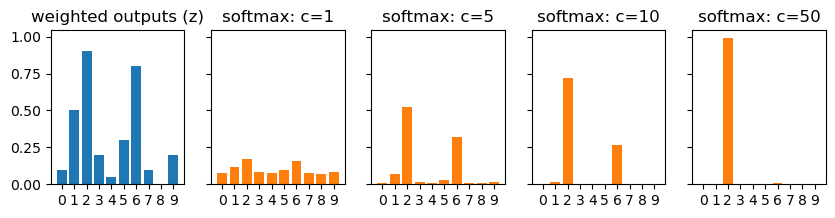

In [ ]:
z = np.array([0.1, 0.5, 0.9, 0.2, 0.05,
              0.3, 0.8, 0.1, 0.0, 0.2 ])
z

fig, ax = plt.subplots(1, 5, figsize=(10, 2), sharey=True)

softmax = lambda z, c: np.exp(c*z) / np.sum(np.exp(c*z))

c_list = [1, 5, 10, 50]
ax[0].bar(range(10), z)
ax[0].set(title="weighted outputs (z)")
for axx in ax:
    axx.set(xticks=range(10),)

for i,axx in enumerate(ax[1:]):
    ax[i+1].bar(range(10), softmax(z, c=c_list[i]), color='tab:orange')
    ax[i+1].set(title=f"softmax: c={c_list[i]}");